In [111]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [112]:
df = pd.read_csv('ensemble_2.csv')

In [113]:
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,7.160466,195.712338,22636.785632,7.235746,336.794067,424.396711,14.376178,68.105888,3.991681,1
1,7.187738,193.202237,21263.028076,7.117409,333.997161,430.163405,14.206928,64.807703,3.957064,0
2,5.400302,140.739062,17266.593422,10.056852,328.358241,472.874073,11.256381,56.931906,4.824786,0
3,7.078913,196.886558,21539.185679,7.104867,335.223406,429.400333,14.344261,65.289765,3.909317,0
4,7.052283,194.971523,21659.468727,7.101790,335.669903,425.620822,14.100794,66.178504,3.989340,0


In [114]:
df.shape

(10000, 10)

In [115]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               10000 non-null  float64
 1   Hardness         10000 non-null  float64
 2   Solids           10000 non-null  float64
 3   Chloramines      10000 non-null  float64
 4   Sulfate          10000 non-null  float64
 5   Conductivity     10000 non-null  float64
 6   Organic_carbon   10000 non-null  float64
 7   Trihalomethanes  10000 non-null  float64
 8   Turbidity        10000 non-null  float64
 9   Potability       10000 non-null  int64  
dtypes: float64(9), int64(1)
memory usage: 781.4 KB


In [116]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ph,10000.0,7.091423,0.706589,0.227499,7.022816,7.093586,7.161077,14.000000
Hardness,10000.0,196.028208,14.636373,73.492234,194.609577,196.057913,197.460684,317.338124
Solids,10000.0,21984.910331,3895.384413,320.942611,21458.018822,21977.488628,22503.494592,56488.672413
Chloramines,10000.0,7.135162,0.710279,1.390871,7.057332,7.133492,7.215818,13.127000
Sulfate,10000.0,333.063156,18.513111,129.000000,331.124701,333.098363,334.943071,481.030642
Conductivity,10000.0,426.360604,36.080914,201.619737,422.515794,426.246982,429.921153,708.226364
Organic_carbon,10000.0,14.339111,1.484742,2.200000,14.188197,14.335375,14.483844,27.006707
Trihalomethanes,10000.0,66.465396,7.182162,8.577013,65.750893,66.469224,67.200320,124.000000
Turbidity,10000.0,3.972793,0.350731,1.450000,3.935476,3.973391,4.010571,6.494749
Potability,10000.0,0.500000,0.500025,0.000000,0.000000,0.500000,1.000000,1.000000


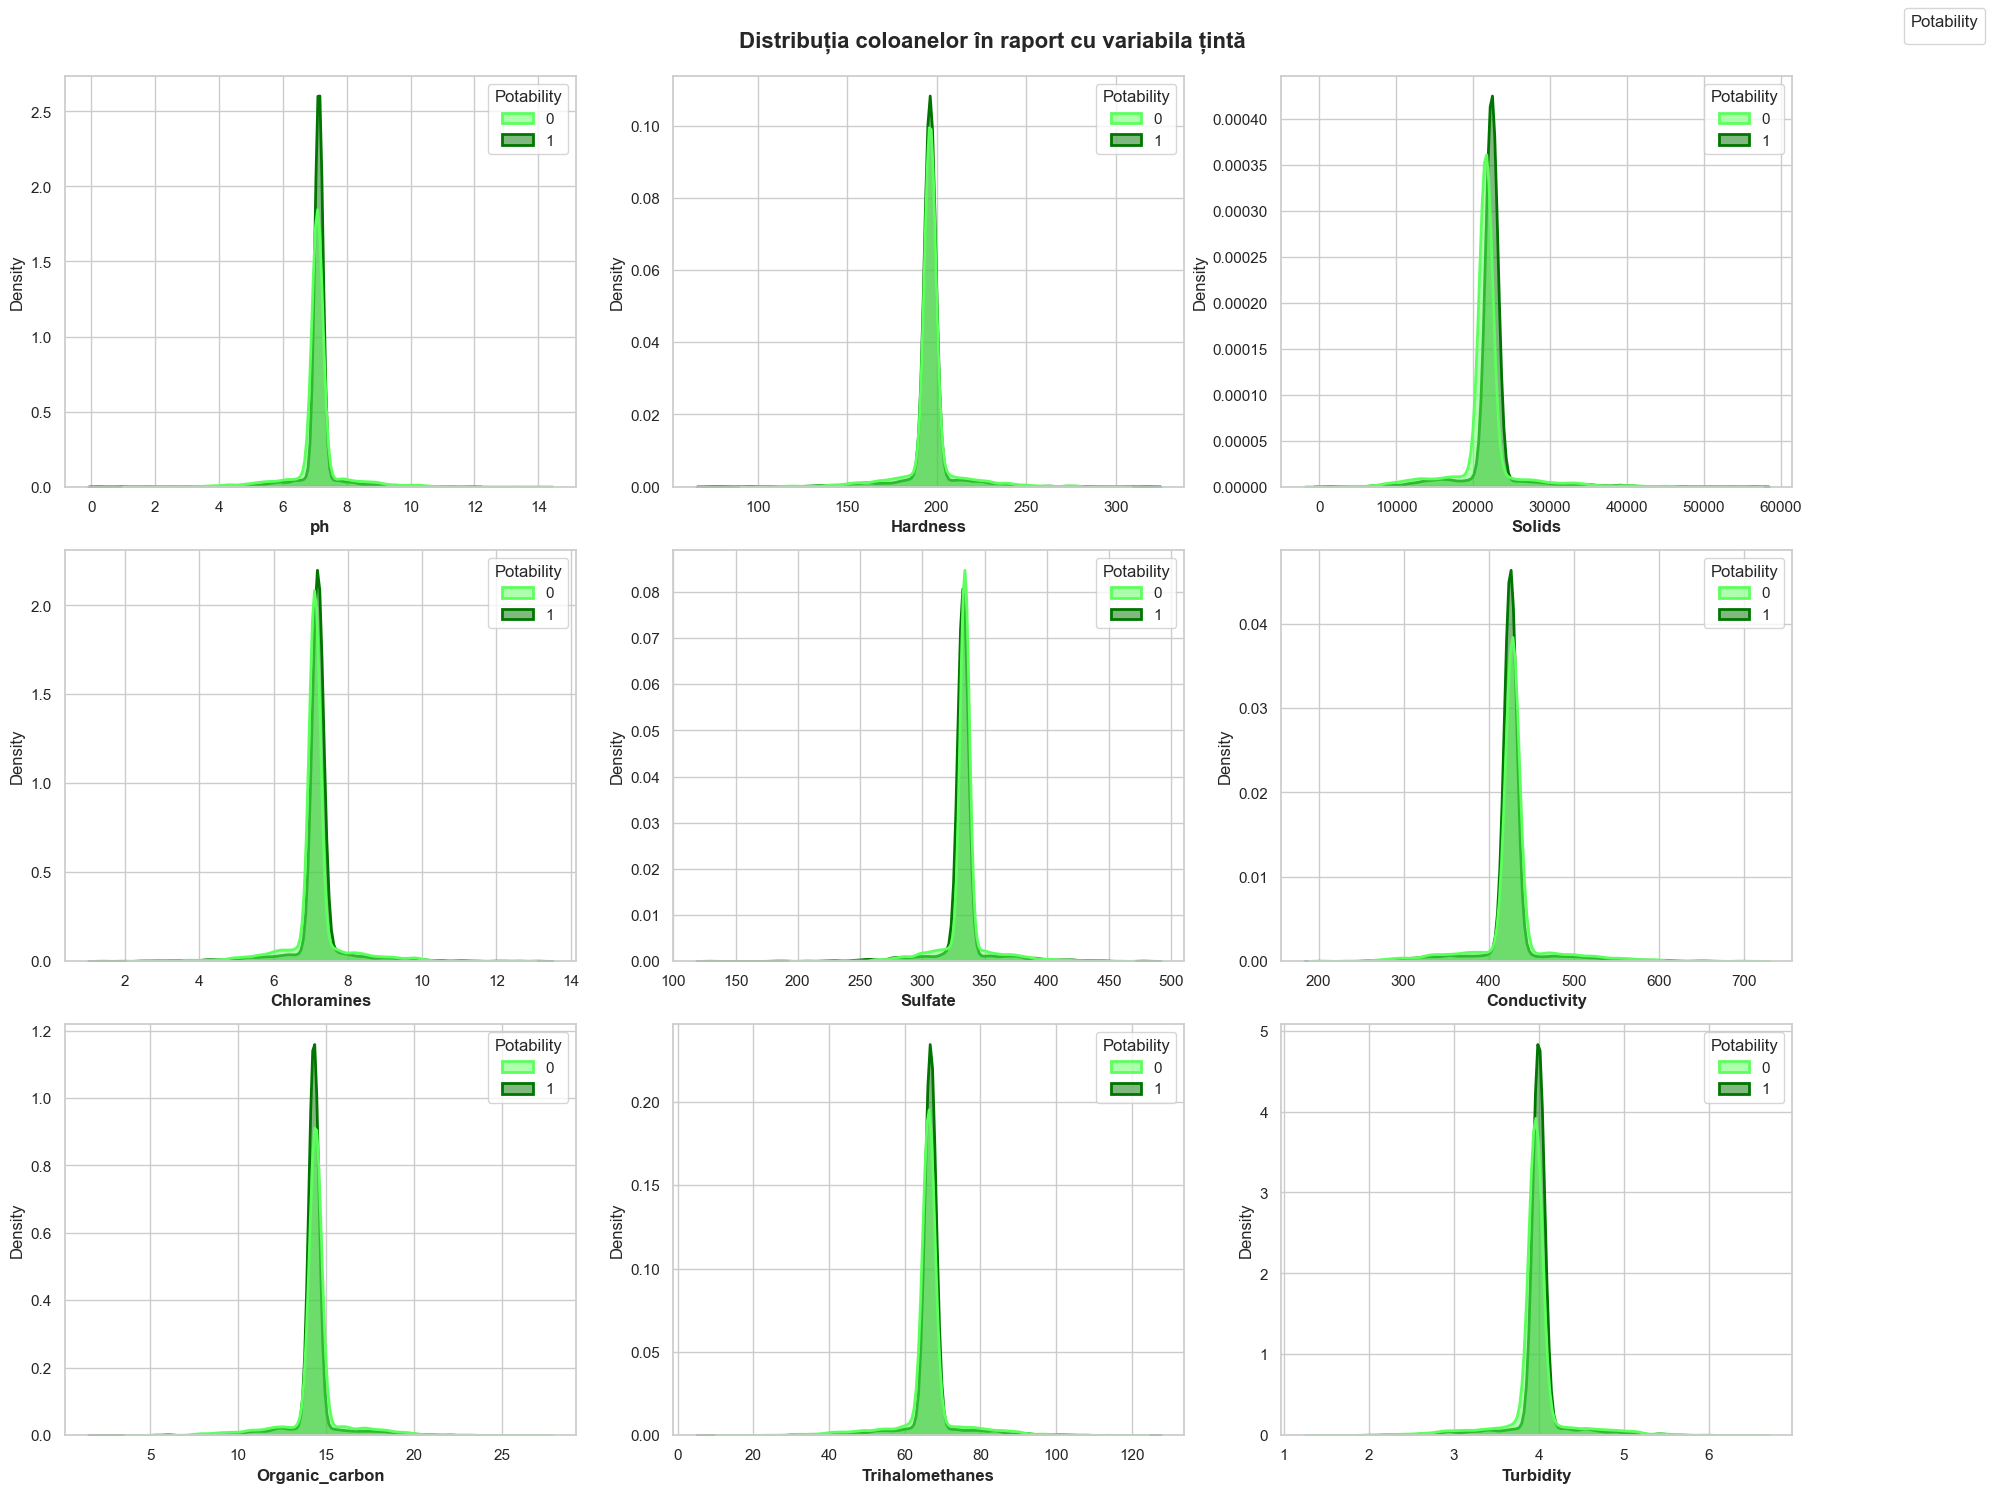

In [117]:
sns.set(style="whitegrid")

columns = df.drop('Potability', axis=1).columns
n_cols = 3
n_rows = (len(columns) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(columns):
    sns.kdeplot(
        x=col, 
        data=df, 
        hue='Potability', 
        fill=True,
        palette=['#5CFF5C', '#007500'], 
        alpha=0.5, 
        lw=2, 
        ax=axes[i],
        common_norm=False
    )
    axes[i].set_xlabel(col, fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Density', fontsize=12)
    
# Setăm legenda doar o singură dată, folosind handles și labels
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='Potability', loc='upper right', fontsize=12)

# Eliminăm axele goale dacă există
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Distribuția coloanelor în raport cu variabila țintă', fontsize=16, fontweight='bold')
plt.subplots_adjust(top=0.95, right=0.9)
plt.show()



Dimensiunea setului de date la aceasta secțiune este 10000 de rnaduri si 10 coloane. Se observa ca setul de date este echilibrat, suprapunandu-se graficele. Acest fapt ind8ica ca puterea predictiva va fi una relativ slaba, relatia dintre variabila tinta si variabilele independente fiihnd una moderata.


In [118]:
df.isna().sum()

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64

In [119]:
df.duplicated().sum()

0

In [120]:

# Dicționar pentru a stoca numărul de outlieri per coloană
outliers_dict = {}

for col in df.drop('Potability', axis=1).columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outliers_dict[col] = outliers.shape[0]

# Afișăm numărul de outlieri pentru fiecare coloană
outliers_series = pd.Series(outliers_dict).sort_values(ascending=False)
print("Numărul de outlieri per coloană (sortat descrescător):")
print(outliers_series)



Numărul de outlieri per coloană (sortat descrescător):
Conductivity       1720
Organic_carbon     1712
Turbidity          1705
ph                 1688
Hardness           1677
Chloramines        1676
Sulfate            1672
Trihalomethanes    1672
Solids             1623
dtype: int64


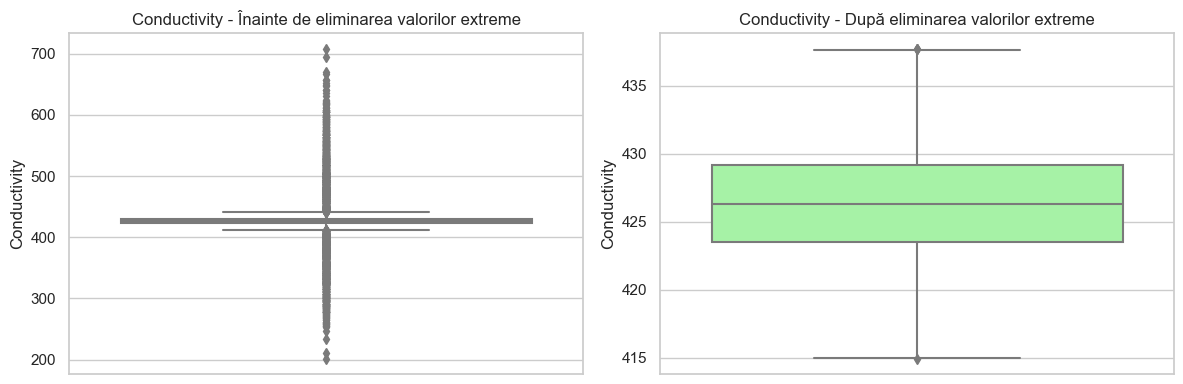

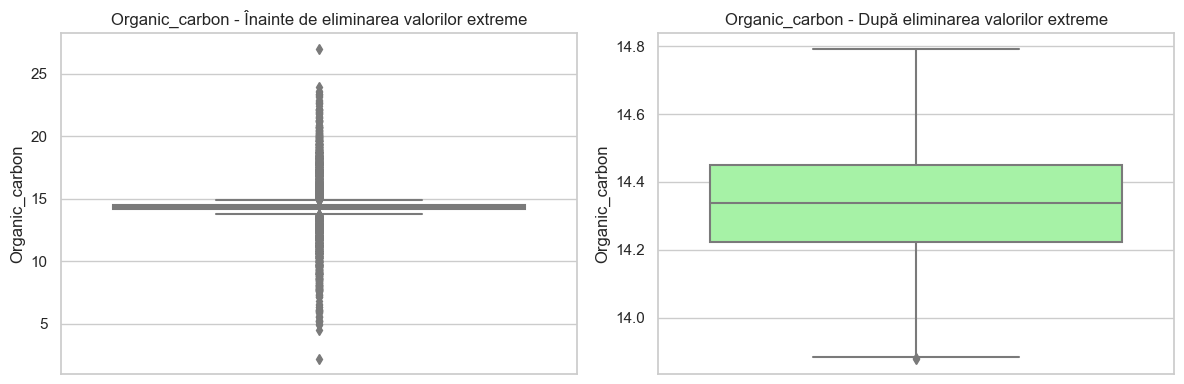

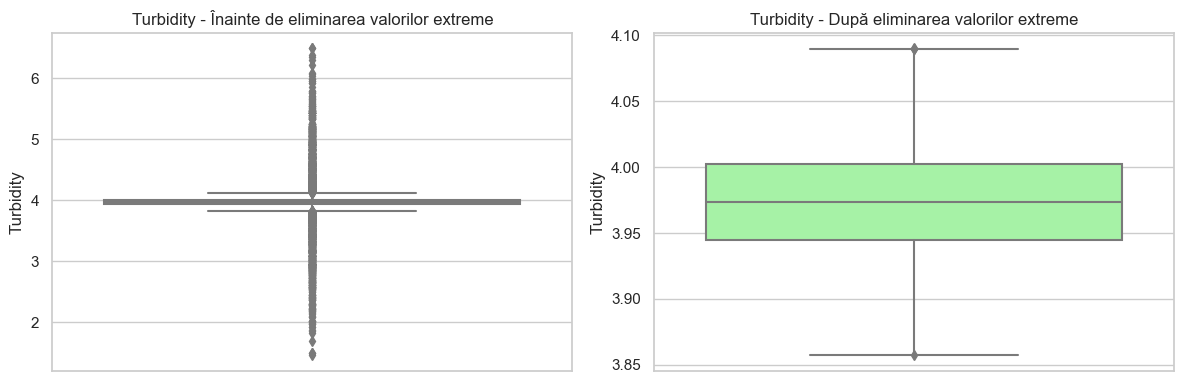

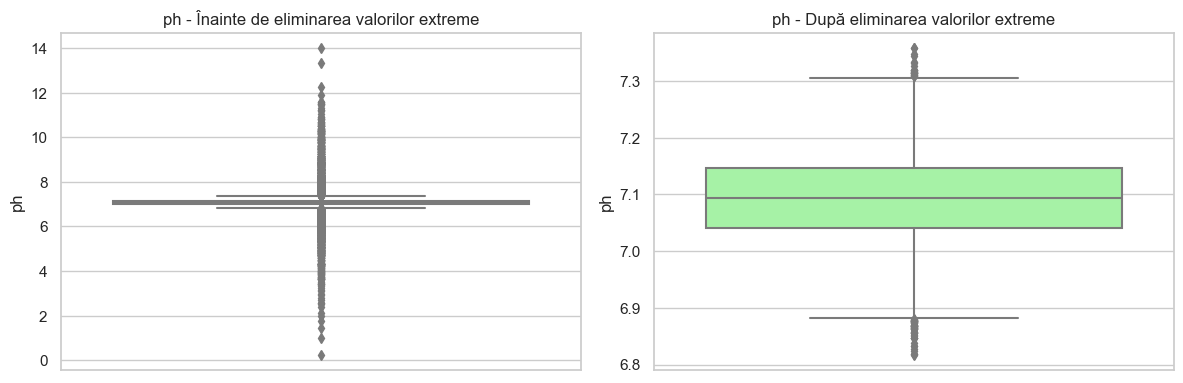

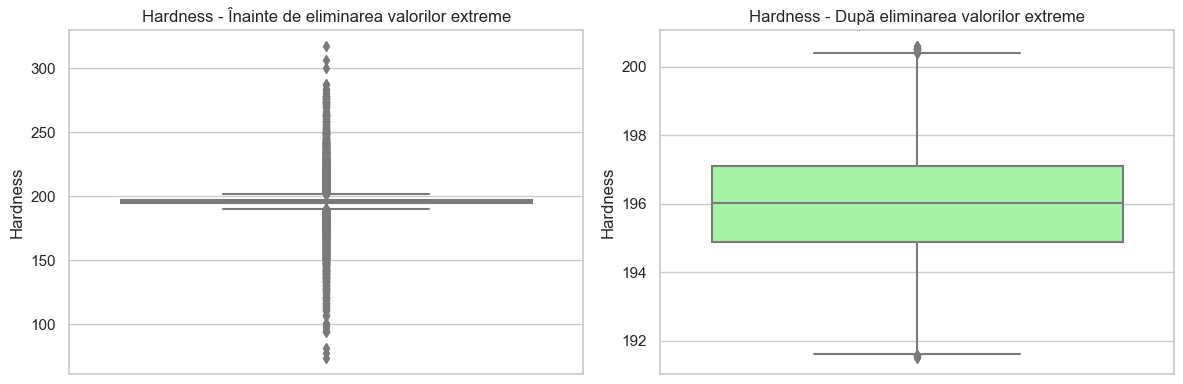

In [121]:

sns.set(style="whitegrid")

# Selectăm primii 5 coloane cu cei mai mulți outlieri
top5_cols = outliers_series.index[:5]

# Copiem dataset-ul pentru comparație
df_before = df.copy()
df_after = df.copy()

# Eliminăm outlierii pentru toate coloanele numerice
for col in df_after.drop('Potability', axis=1).columns:
    Q1 = df_after[col].quantile(0.25)
    Q3 = df_after[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_after = df_after[(df_after[col] >= lower_bound) & (df_after[col] <= upper_bound)]

# Vizualizare boxplot înainte și după pentru primii 5 outlieri
for col in top5_cols:
    plt.figure(figsize=(12,4))

    # Boxplot înainte
    plt.subplot(1,2,1)
    sns.boxplot(y=df_before[col], color='#FF9999')
    plt.title(f'{col} - Înainte de eliminarea valorilor extreme')

    # Boxplot după eliminare
    plt.subplot(1,2,2)
    sns.boxplot(y=df_after[col], color='#99FF99')
    plt.title(f'{col} - După eliminarea valorilor extreme')

    plt.tight_layout()
    plt.show()


In [122]:
df.dtypes

ph                 float64
Hardness           float64
Solids             float64
Chloramines        float64
Sulfate            float64
Conductivity       float64
Organic_carbon     float64
Trihalomethanes    float64
Turbidity          float64
Potability           int64
dtype: object

In [123]:
# Selectarea coloanelor numerice 
numerical = df.select_dtypes(include=['number']).columns.tolist()

# Selectarea coloanele categorice (de tip obiect) 
categorical = df.select_dtypes(include=['object']).columns.tolist()

# Afișarea rezultatelor
print('Coloane numerice:', numerical)
print('Coloane categorice:', categorical)

Coloane numerice: ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'Potability']
Coloane categorice: []


In [124]:
df.shape

(10000, 10)

 Dupa cum se poate observa in set de date  nu exista variabile lipsa sau duplicate. Valorile extreme gasite au fost eliminate. Exista 9 variabile numerice si o variabila categoriala "Potability", care este variabila tinta, deja codificata numeric. Dimensiunea setului de date nu se modifica la aceasta sectiune.

In [125]:
corr = df.corr()
corr

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
ph,1.000000,0.107334,-0.081289,-0.019698,0.008764,0.007531,0.027975,0.018940,-0.035208,0.032668
Hardness,0.107334,1.000000,-0.050486,-0.016832,-0.109845,0.004295,0.011851,-0.012704,-0.032030,-0.000324
Solids,-0.081289,-0.050486,1.000000,-0.050633,-0.162257,-0.004203,-0.002350,-0.013560,0.023074,0.095617
Chloramines,-0.019698,-0.016832,-0.050633,1.000000,0.010191,-0.025033,-0.023198,0.019057,0.015629,0.058243
Sulfate,0.008764,-0.109845,-0.162257,0.010191,1.000000,-0.017498,0.027896,-0.027109,-0.011495,-0.038707
Conductivity,0.007531,0.004295,-0.004203,-0.025033,-0.017498,1.000000,0.014415,0.003652,0.014103,-0.032677
Organic_carbon,0.027975,0.011851,-0.002350,-0.023198,0.027896,0.014415,1.000000,-0.008310,-0.015844,-0.032175
Trihalomethanes,0.018940,-0.012704,-0.013560,0.019057,-0.027109,0.003652,-0.008310,1.000000,-0.019916,0.029687
Turbidity,-0.035208,-0.032030,0.023074,0.015629,-0.011495,0.014103,-0.015844,-0.019916,1.000000,0.051648
Potability,0.032668,-0.000324,0.095617,0.058243,-0.038707,-0.032677,-0.032175,0.029687,0.051648,1.000000


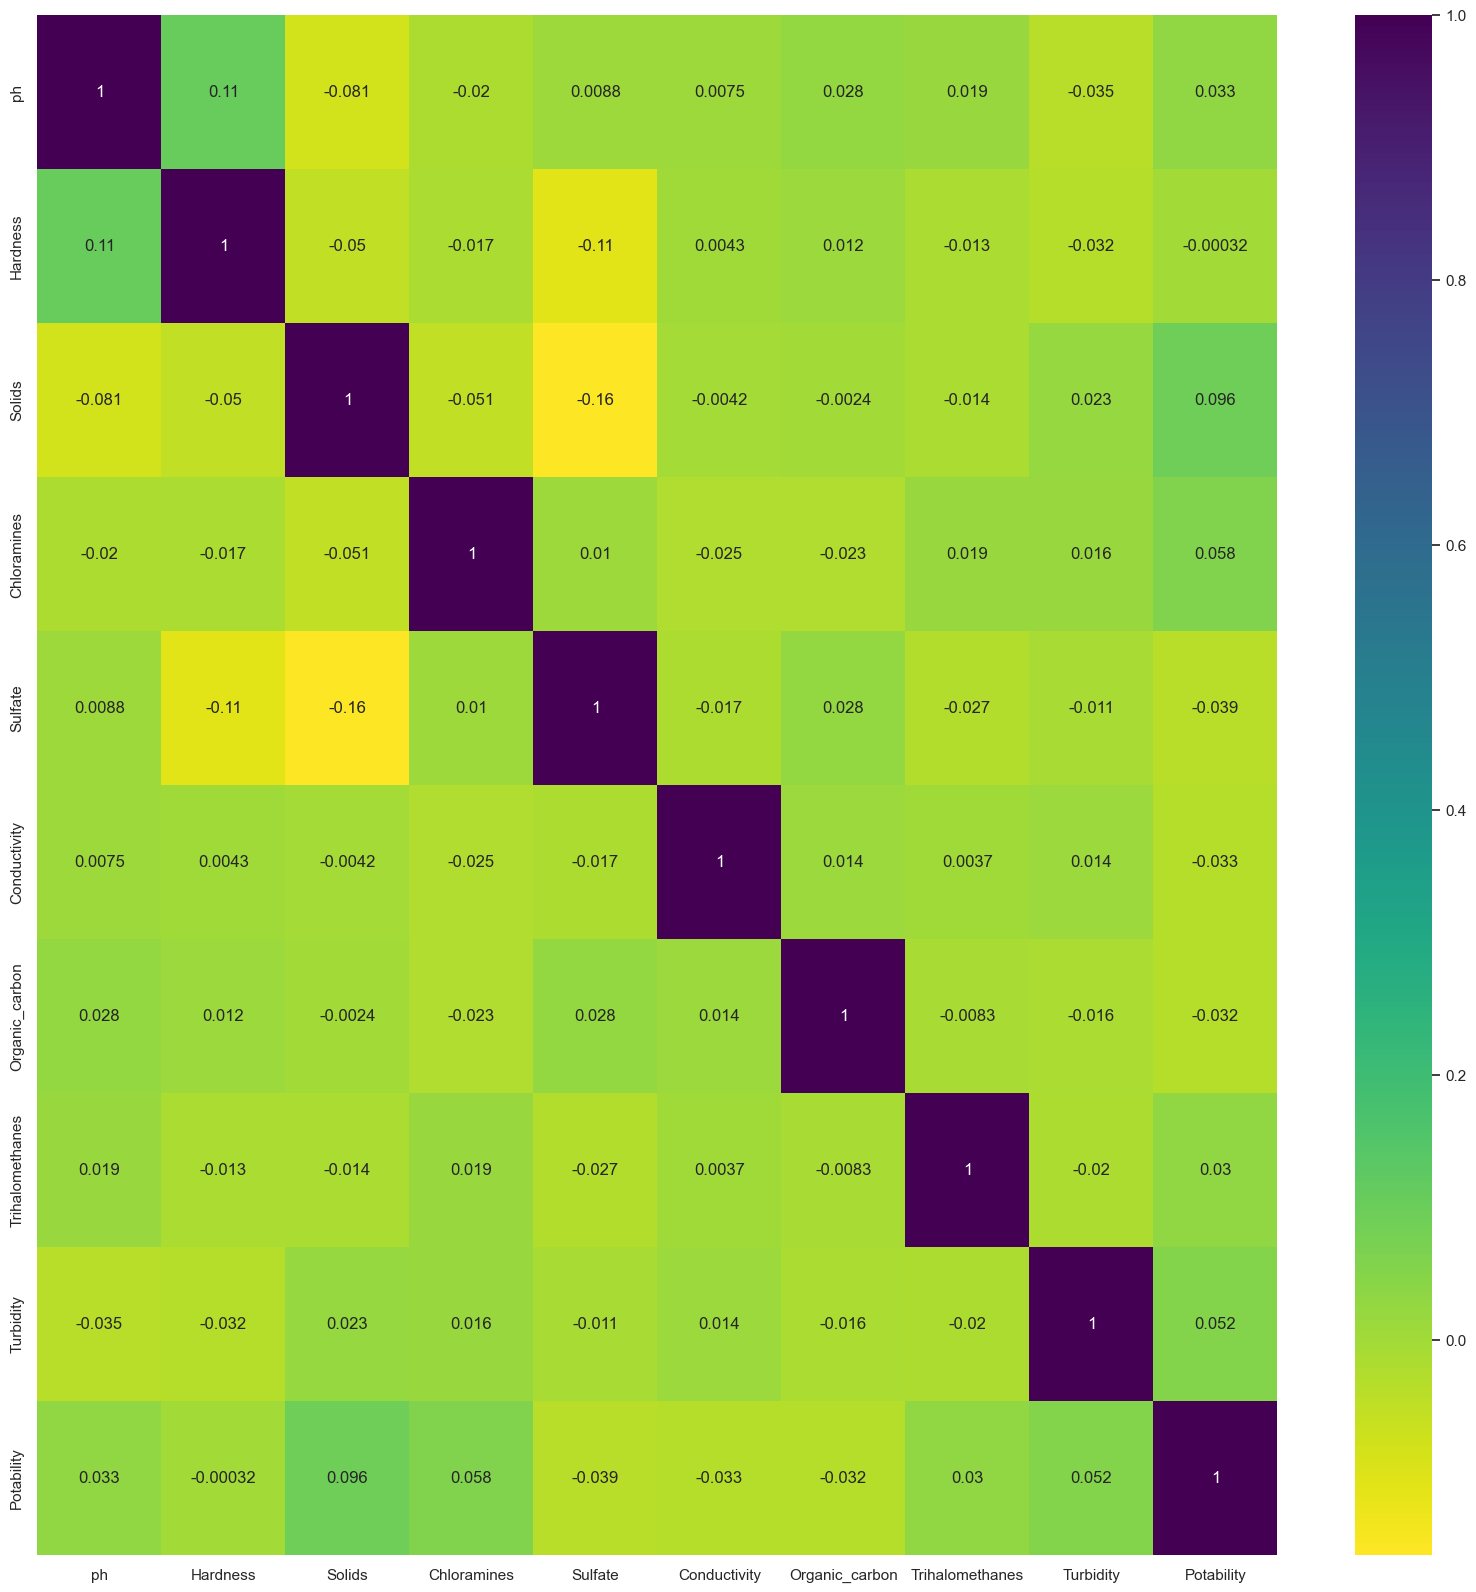

In [126]:

# Calculăm matricea de corelație între toate coloanele numerice
corr = df.corr()

# Setăm dimensiunea figurii
plt.figure(figsize=(20,20))

# Creăm heatmap-ul cu corelațiile
sns.heatmap(corr, cmap='viridis_r', annot=True)

# Afișăm figura
plt.show()


In [127]:
from sklearn.model_selection import train_test_split

# Separăm variabilele independente (X) de variabila țintă (y)
X = df.drop('Potability', axis=1)  # toate coloanele, mai puțin 'diagnosis'
y = df['Potability']               # variabila țintă

# Împărțim dataset-ul în set de antrenament și set de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Verificăm dimensiunile dataset-urilor
print("Dimensiune X_train:", X_train.shape)
print("Dimensiune X_test:", X_test.shape)
print("Dimensiune y_train:", y_train.shape)
print("Dimensiune y_test:", y_test.shape)


Dimensiune X_train: (7000, 9)
Dimensiune X_test: (3000, 9)
Dimensiune y_train: (7000,)
Dimensiune y_test: (3000,)


In [128]:
from sklearn.preprocessing import StandardScaler

# Inițializăm scaler-ul
scaler = StandardScaler()

# Aplicăm scalarea pe setul de antrenament și test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convertim în DataFrame păstrând numele coloanelor
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

# Verificăm primele rânduri
print("X_train_scaled_df:")
display(X_train_scaled_df.head())

print("X_test_scaled_df:")
display(X_test_scaled_df.head())


X_train_scaled_df:


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
9069,-0.873985,0.644534,-0.674305,1.086596,1.933906,1.517160,1.002093,-1.357811,-4.409858
2603,-0.199164,-0.011506,-0.169048,-0.021278,-0.083183,0.021760,0.065924,0.148447,-0.036968
7738,0.102564,0.048369,0.036045,0.103538,0.014337,0.049458,0.208872,0.037340,0.143774
1579,-0.057148,0.172711,-0.171779,-0.113995,0.069220,0.038032,-0.016315,-0.011669,-0.018334
5058,0.014397,-0.017475,0.042246,-0.194705,-0.247769,0.127476,-0.141733,-0.086527,0.008669


X_test_scaled_df:


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
6252,0.078565,0.006894,0.402830,-0.017842,-0.125866,-0.002316,-0.073741,0.103478,-0.014444
4684,-0.090186,-0.181972,-0.005048,0.047080,0.150440,-0.039927,0.052661,0.059069,0.108261
1731,-0.216653,-0.011729,-0.163894,-0.081888,-0.081769,-0.031430,0.136916,-0.166747,0.045311
4742,-0.144619,0.059730,-0.132371,-0.082001,-0.082116,-0.102628,0.181233,0.071679,-0.113248
4521,-1.558737,0.676858,-1.776132,0.640319,-1.399409,0.154675,-0.078061,-1.879115,1.307940


Mulicoliniaritatea se gestionează elimininad coloanele puternic corelate cu variabila tinta. Din matricea noastra de corelatie se observa ca nu exista variabile independente puternic corelate cu "Potability" (>0.8), astfel nu mai este necesara eliminarea coloanelor puternic corelate.
Dimensiunile seturilor de antrenare și de testare sunt :
Dimensiune X_train: (7000, 9)
Dimensiune X_test: (3000, 9)
Dimensiune y_train: (7000,)
Dimensiune y_test: (3000,)

In [129]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report


# Creăm modelul implicit (fără setarea max_depth sau min_samples_split)
dt_default = DecisionTreeClassifier(random_state=42)
dt_default.fit(X_train_scaled_df, y_train)

# Predicții pe train și test
y_train_pred = dt_default.predict(X_train_scaled_df)
y_test_pred = dt_default.predict(X_test_scaled_df)

# Acuratețe
acc_train = accuracy_score(y_train, y_train_pred)
acc_test = accuracy_score(y_test, y_test_pred)

print("=== Model Implicit ===")
print(f"Acuratețe Train: {acc_train:.3f}")
print(f"Acuratețe Test: {acc_test:.3f}")
print("\nClassification Report (Test):\n", classification_report(y_test, y_test_pred))


=== Model Implicit ===
Acuratețe Train: 1.000
Acuratețe Test: 0.774

Classification Report (Test):
               precision    recall  f1-score   support

           0       0.79      0.76      0.77      1520
           1       0.76      0.79      0.77      1480

    accuracy                           0.77      3000
   macro avg       0.77      0.77      0.77      3000
weighted avg       0.77      0.77      0.77      3000



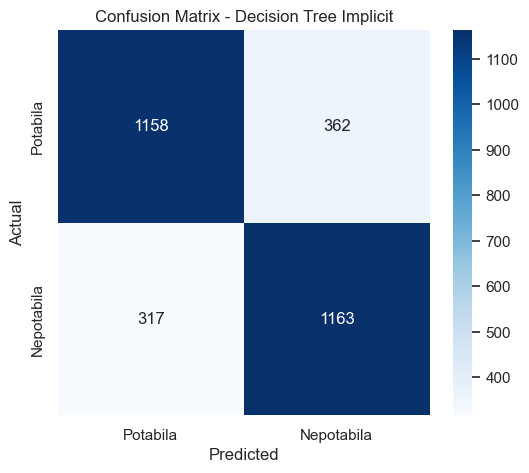

In [130]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Calculăm matricea de confuzie
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Potabila','Nepotabila'], yticklabels=['Potabila','Nepotabila'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Decision Tree Implicit')
plt.show()

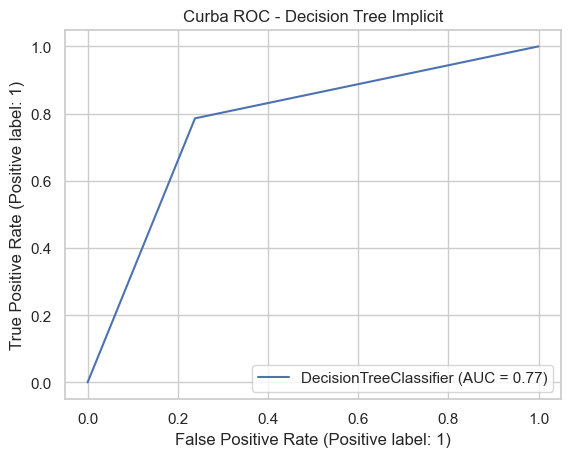

In [131]:
from sklearn.metrics import RocCurveDisplay


# Curba ROC direct din model
RocCurveDisplay.from_estimator(
    dt_default,          # modelul antrenat
    X_test_scaled_df,    # datele de test
    y_test               # etichetele reale
)

plt.title("Curba ROC - Decision Tree Implicit")
plt.show()


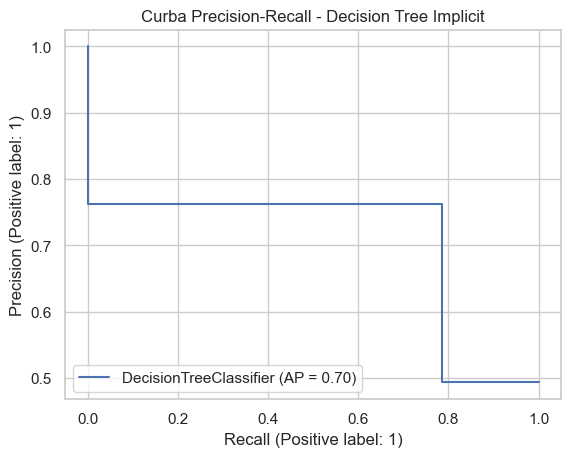

In [132]:
from sklearn.metrics import PrecisionRecallDisplay
import matplotlib.pyplot as plt

# Curba Precision-Recall
PrecisionRecallDisplay.from_estimator(
    dt_default,          # modelul antrenat
    X_test_scaled_df,    # datele de test
    y_test               # etichetele reale
)

plt.title("Curba Precision-Recall - Decision Tree Implicit")
plt.show()


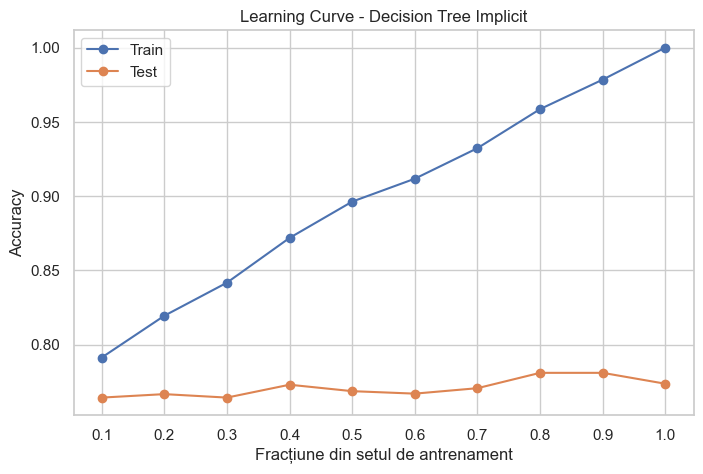

In [133]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Listă de dimensiuni pentru subsetul de antrenament
train_sizes_list = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

accuracy_train = []
accuracy_test = []

for frac in train_sizes_list:
    n_train = int(len(X_train_scaled_df) * frac)
    
    # Subset din setul de antrenament
    X_train_subset = X_train_scaled_df.iloc[:n_train]
    y_train_subset = y_train.iloc[:n_train]
    
    # Model implicit
    model = DecisionTreeClassifier(random_state=42)
    model.fit(X_train_subset, y_train_subset)
    
    # Predicții
    y_train_pred = model.predict(X_train_scaled_df)
    y_test_pred = model.predict(X_test_scaled_df)
    
    # Accuracy
    accuracy_train.append(accuracy_score(y_train, y_train_pred))
    accuracy_test.append(accuracy_score(y_test, y_test_pred))

# Plot simplu, ca în exemplul tău cu min_samples_split
plt.figure(figsize=(8,5))
plt.plot(train_sizes_list, accuracy_train, marker='o')
plt.plot(train_sizes_list, accuracy_test, marker='o')
plt.title('Learning Curve - Decision Tree Implicit')
plt.xlabel('Fracțiune din setul de antrenament')
plt.ylabel('Accuracy')
plt.xticks(train_sizes_list)
plt.grid(True)
plt.legend(['Train', 'Test'])
plt.show()


Modelul prezintă o acuratețe perfectă pe setul de antrenament (1.000), sugerând o supraadaptare (overfitting) pronunțată la datele de instruire.
Pe setul de date de testare (cu o acuratețe generală de 77.4%).
Analiza detaliată prin raportul de clasificare dezvăluie o performanta optimala (0.79, respectiv 0.76) pentru Clasa 0.
De asemenea, performanța pentru Clasa 1 este relativ asemanatoare cu cea pentru Clasa 0, avand precizii destul de apropiate(+/_ 0.03).  Valorile din matricea de confuzie  arata numarul de predictii corecte si incorecte, astfel numarul  cazurile  in care apa este potabila si sunt prezise corect este 1158, numarul cazurilor in care apa nu este potabila si sunt prezise corect este 1163, numarul cazurilor in care apa  este potabila si sunt  prezise incorect este 362 si numarul cazurilor in care apa nu este potabila si sunt prezise incorect 317. O valoare AUC de 0.77 indică faptul că modelul are o anumită putere de predicție, fiind mai bun decât ghicirea aleatorie.

In [134]:
from sklearn.ensemble import RandomForestClassifier

# Model implicit Random Forest
rf_default = RandomForestClassifier(random_state=42)
rf_default.fit(X_train_scaled_df, y_train)

# Predicții
y_train_pred = rf_default.predict(X_train_scaled_df)
y_test_pred = rf_default.predict(X_test_scaled_df)

# Acuratețe
print("=== Random Forest Implicit ===")
print(f"Acuratețe Train: {accuracy_score(y_train, y_train_pred):.3f}")
rf_train=accuracy_score(y_train, y_train_pred)
print(f"Acuratețe Test: {accuracy_score(y_test, y_test_pred):.3f}")
rf_test=accuracy_score(y_test, y_test_pred)

# Classification Report
print("\nClassification Report (Test):\n", classification_report(y_test, y_test_pred))



=== Random Forest Implicit ===
Acuratețe Train: 1.000
Acuratețe Test: 0.838

Classification Report (Test):
               precision    recall  f1-score   support

           0       0.83      0.86      0.84      1520
           1       0.85      0.81      0.83      1480

    accuracy                           0.84      3000
   macro avg       0.84      0.84      0.84      3000
weighted avg       0.84      0.84      0.84      3000



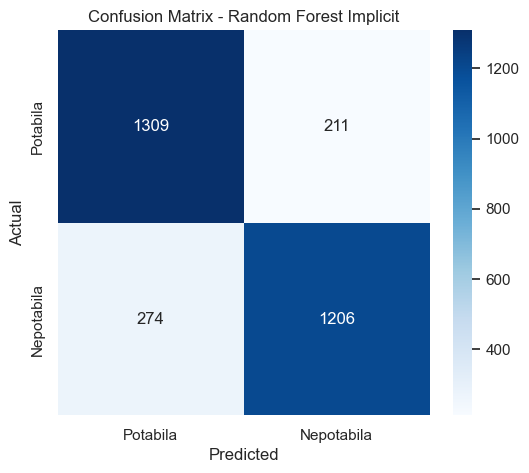

In [135]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Potabila','Nepotabila'], yticklabels=['Potabila','Nepotabila'])
plt.title('Confusion Matrix - Random Forest Implicit')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


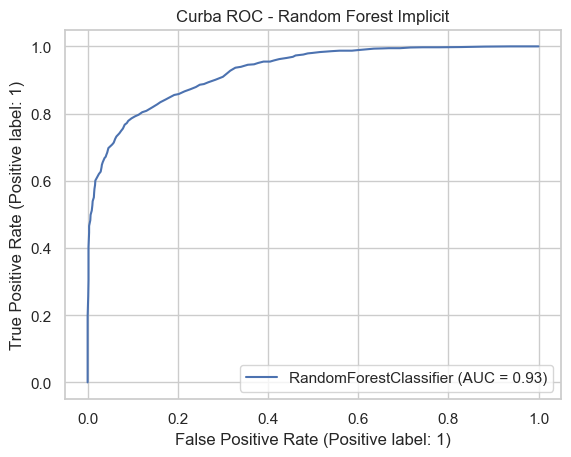

In [136]:
from sklearn.metrics import RocCurveDisplay


# Curba ROC direct din model
RocCurveDisplay.from_estimator(
    rf_default,          # modelul antrenat
    X_test_scaled_df,    # datele de test
    y_test               # etichetele reale
)

plt.title("Curba ROC - Random Forest Implicit")
plt.show()

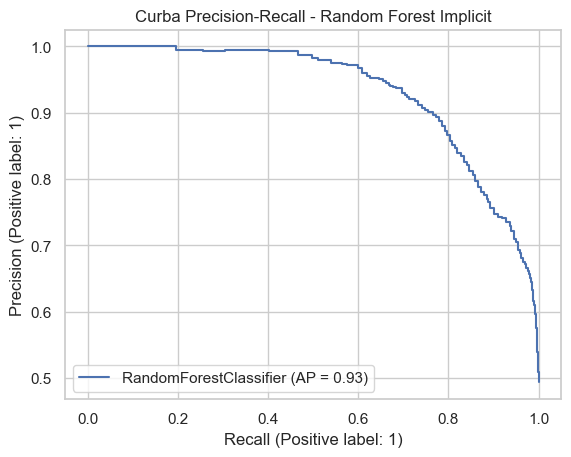

In [137]:
from sklearn.metrics import PrecisionRecallDisplay
import matplotlib.pyplot as plt

# Curba Precision-Recall
PrecisionRecallDisplay.from_estimator(
    rf_default,          # modelul antrenat
    X_test_scaled_df,    # datele de test
    y_test               # etichetele reale
)

plt.title("Curba Precision-Recall - Random Forest Implicit")
plt.show()

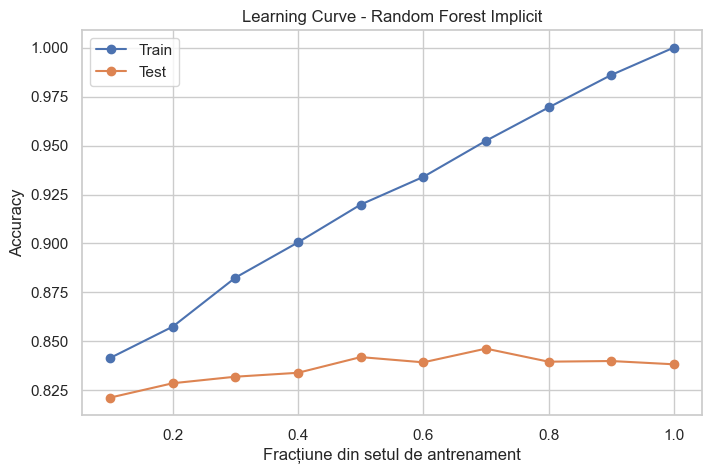

In [138]:
# Learning Curve simplu
train_sizes_list = np.linspace(0.1, 1.0, 10)
accuracy_train = []
accuracy_test = []

for frac in train_sizes_list:
    n_train = int(len(X_train_scaled_df) * frac)
    X_train_subset = X_train_scaled_df.iloc[:n_train]
    y_train_subset = y_train.iloc[:n_train]
    
    model = RandomForestClassifier(random_state=42)
    model.fit(X_train_subset, y_train_subset)
    
    y_train_pred_full = model.predict(X_train_scaled_df)
    y_test_pred_full = model.predict(X_test_scaled_df)
    
    accuracy_train.append(accuracy_score(y_train, y_train_pred_full))
    accuracy_test.append(accuracy_score(y_test, y_test_pred_full))

plt.figure(figsize=(8,5))
plt.plot(train_sizes_list, accuracy_train, marker='o')
plt.plot(train_sizes_list, accuracy_test, marker='o')
plt.title('Learning Curve - Random Forest Implicit')
plt.xlabel('Fracțiune din setul de antrenament')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend(['Train', 'Test'])
plt.show()



Modelul are o performanță generală  bună (acuratețe de 83.8%). Totuși, există o discrepanță între performanța pe setul de antrenament (perfectă) și setul de test, ceea ce sugerează un ușor overfitting. Se observa o imbunatatire a performantei fata de cea a arborelui de decizie care lua valori in intervalul 76-79%. Valorile din matricea de confuzie arata numarul de predictii corecte si incorecte, astfel numarul cazurile in care apa este potabila si sunt prezise corect este 1308, numarul cazurilor in care apa nu este potabila si sunt prezise corect este 1206, numarul cazurilor in care apa este potabila si sunt prezise incorect este 211 si numarul cazurilor in care apa nu este potabila si sunt prezise incorect 276. Graficul pentru curba ROC  indică o performanță buna a modelului RandomForest (0.93), capabil să prezică  ambele clase (potabila si nepotabila ) cu o acuratețe buna pe setul de date curent.

In [139]:
from sklearn.ensemble import AdaBoostClassifier

ada_default = AdaBoostClassifier(random_state=42, algorithm='SAMME')
ada_default.fit(X_train_scaled_df, y_train)

# Predicții
y_train_pred = ada_default.predict(X_train_scaled_df)
y_test_pred = ada_default.predict(X_test_scaled_df)

# Evaluare
print("=== AdaBoost Implicit ===")
print(f"Accuracy Train: {accuracy_score(y_train, y_train_pred):.3f}")
ada_train=accuracy_score(y_train, y_train_pred)
print(f"Accuracy Test: {accuracy_score(y_test, y_test_pred):.3f}")
ada_test=accuracy_score(y_test, y_test_pred)
print("\nClassification Report (Test):\n", classification_report(y_test, y_test_pred))


=== AdaBoost Implicit ===
Accuracy Train: 0.826
Accuracy Test: 0.788

Classification Report (Test):
               precision    recall  f1-score   support

           0       0.79      0.78      0.79      1520
           1       0.78      0.79      0.79      1480

    accuracy                           0.79      3000
   macro avg       0.79      0.79      0.79      3000
weighted avg       0.79      0.79      0.79      3000



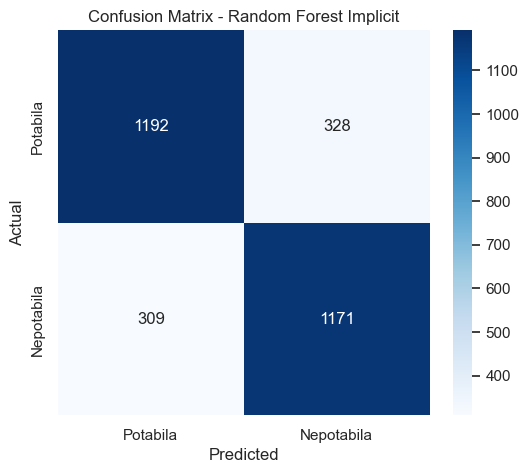

In [140]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Potabila','Nepotabila'], yticklabels=['Potabila','Nepotabila'])
plt.title('Confusion Matrix - Random Forest Implicit')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

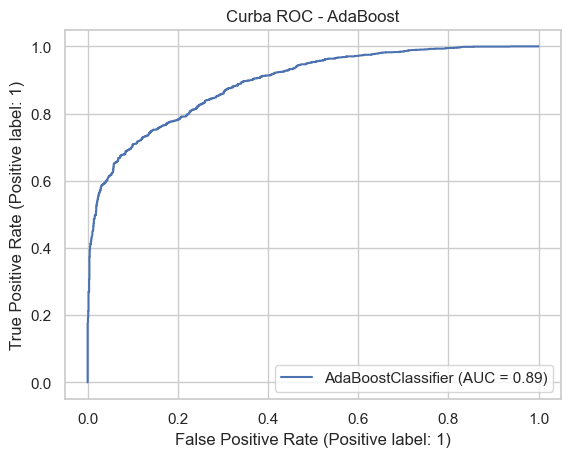

In [141]:
from sklearn.metrics import RocCurveDisplay


# Curba ROC direct din model
RocCurveDisplay.from_estimator(
    ada_default,          # modelul antrenat
    X_test_scaled_df,    # datele de test
    y_test               # etichetele reale
)

plt.title("Curba ROC - AdaBoost")
plt.show()

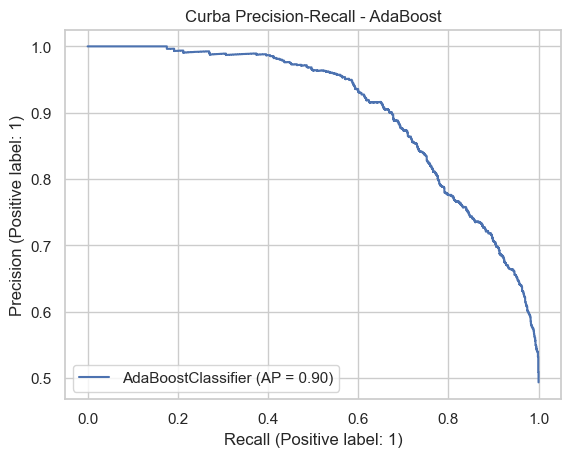

In [142]:
from sklearn.metrics import PrecisionRecallDisplay
import matplotlib.pyplot as plt

# Curba Precision-Recall
PrecisionRecallDisplay.from_estimator(
    ada_default,          # modelul antrenat
    X_test_scaled_df,    # datele de test
    y_test               # etichetele reale
)

plt.title("Curba Precision-Recall - AdaBoost")
plt.show()

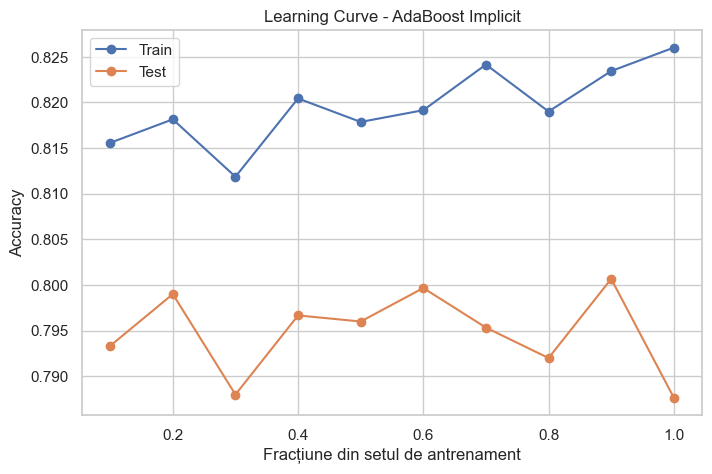

In [143]:
# Learning curve simplu
train_sizes_list = np.linspace(0.1, 1.0, 10)
accuracy_train = []
accuracy_test = []

for frac in train_sizes_list:
    n_train = int(len(X_train_scaled_df) * frac)
    X_train_subset = X_train_scaled_df.iloc[:n_train]
    y_train_subset = y_train.iloc[:n_train]
    
    model = AdaBoostClassifier(random_state=42, algorithm='SAMME')
    model.fit(X_train_subset, y_train_subset)
    
    y_train_pred_full = model.predict(X_train_scaled_df)
    y_test_pred_full = model.predict(X_test_scaled_df)
    
    accuracy_train.append(accuracy_score(y_train, y_train_pred_full))
    accuracy_test.append(accuracy_score(y_test, y_test_pred_full))

plt.figure(figsize=(8,5))
plt.plot(train_sizes_list, accuracy_train, marker='o')
plt.plot(train_sizes_list, accuracy_test, marker='o')
plt.title('Learning Curve - AdaBoost Implicit')
plt.xlabel('Fracțiune din setul de antrenament')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend(['Train', 'Test'])
plt.show()


Ce reprezintă valorile din matricea de confuzie și curba ROC pentru model? 
Acuratețea globală pe setul de testare este de 78.8%. Se observa o scadere a acuratetei fata de cea a modelului Random Forest care este de 83.8%. Valorile din matricea de confuzie arata numarul de predictii corecte si incorecte, astfel numarul cazurile in care apa este potabila si sunt prezise corect este 1192, numarul cazurilor in care apa nu este potabila si sunt prezise corect este 1171, numarul cazurilor in care apa este potabila si sunt prezise incorect este 328 si numarul cazurilor in care apa nu este potabila si sunt prezise incorect 309. Graficul pentru curba ROC indică o performanță buna a modelului RandomForest (0.89), capabil să prezică ambele clase (potabila si nepotabila ) cu o acuratețe buna pe setul de date curent.

In [144]:
# -----------------------------
# Crearea unui DataFrame pentru compararea modelelor
# -----------------------------

import pandas as pd

models = pd.DataFrame({
    'Model': [
        'Decision Tree',   # Numele modelului Logistic Regression
        'Random Forest',           # Numele modelului Gaussian Naive Bayes
        'AdaBoost'         # Numele modelului Decision Tree
    ],
    'Training Accuracy': [
        acc_train, rf_train, ada_train # Acuratețea pe setul de training
    ],
    'Test Accuracy': [
        acc_test, rf_test, ada_test  # Acuratețea pe setul de training
    ]
})

# Afișarea DataFrame-ul
models

,Model,Training Accuracy,Test Accuracy
0,Decision Tree,1.000,0.773667
1,Random Forest,1.000,0.838333
2,AdaBoost,0.826,0.787667


Modelul care a oferit cea mai buna performanta este Random Forest. 
Toate cele 3 modele au obtinut rezultate bune. Modelul Random Forest a depasit Decision Tree ul, deoarece a crescut precizia.